# Stage 3 — Hydrological Connectivity (Mole Creek prototype)

Answers a different question from Stage 2: not "where is karst?" but
"where could something happening at the surface actually reach the
karst?"

**Inputs:**
- `KPROXCATCH` — Karst Atlas field for proximal (allogenic) catchments
  draining directly into karst. **Important, confirmed from the data
  dictionary:** its A-D values classify *the karst area it drains into*,
  not the connectivity strength of the catchment itself — so a value of
  "A" doesn't mean "very well connected," it means "drains into a
  Category A karst area." Treated here as presence/absence, not an
  ordinal score.
- `KDISTCATCH` — distal catchments (whole upstream river catchment).
  Per the data dictionary, these generally have less direct effect on
  karst processes than proximal catchments, so scored lower.
- DEM-derived flow accumulation (WhiteboxTools) — an independent
  physical check against the Atlas classification.
- The exposure type from Stage 2: exposed/covered karst is **autogenic**
  (recharges from its own rainfall); interstratal is not.

**A boundary problem found and fixed before this notebook could produce
anything meaningful:** the Mole Creek study boundary (Stage 0) was
originally just the union of the karst polygons themselves — 99.9997%
covered by karst/catchment features, with no surrounding land at all.
That made any "connectivity" layer meaningless (everything scored
maximum, since there was no background left to score lower) and would
have broken Stage 5 (land-use pressure) the same way, since there'd be
no non-karst land to carry a pressure signal. Fixed by buffering the
Mole Creek boundary by 3 km in Stage 0 before continuing here.

In [1]:
from pathlib import Path
import os
import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import rasterize
import matplotlib.pyplot as plt
import whitebox

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
outpath = data / "Output_data"

karst_mc = gpd.read_file(str(outpath / "karst_mc_EPSG7855.gpkg"))
karst_mc = karst_mc[karst_mc.geom_type.isin(["Polygon", "MultiPolygon"])].copy()

## 3.1 Atlas-based connectivity score

Combines three signals, taking the **max** per polygon (a polygon can
be karst itself *and* separately flagged as a catchment for an adjacent
karst area — confirmed in the real data, this isn't hypothetical):

- **Autogenic** (from Stage 2's exposure type): exposed/covered = 3, interstratal = 2, non-karst = 0
- **Proximal catchment** (`KPROXCATCH` != 0): 3
- **Distal catchment** (`KDISTCATCH` != 0): 1 (lower — per the data dictionary, less direct effect)

In [2]:
AUTOGENIC_SCORE = {"exposed": 3, "covered": 3, "interstratal": 2, "non-karst": 0}
karst_mc["autogenic_score"] = karst_mc["exposure_type"].map(AUTOGENIC_SCORE)
karst_mc["proximal_score"] = np.where(karst_mc["KPROXCATCH"] != "0", 3, 0)
karst_mc["distal_score"] = np.where(karst_mc["KDISTCATCH"].astype(str) != "0", 1, 0)

karst_mc["connectivity"] = karst_mc[["autogenic_score", "proximal_score", "distal_score"]].max(axis=1)
print("Connectivity score distribution (polygon count):")
print(karst_mc["connectivity"].value_counts().sort_index())
print()
print("Which component drove each score, by exposure type:")
print(pd.crosstab(karst_mc["connectivity"], karst_mc["exposure_type"]))

karst_mc.to_file(outpath / "karst_mc_EPSG7855.gpkg", driver="GPKG")

Connectivity score distribution (polygon count):
connectivity
0     5
3    85
Name: count, dtype: int64

Which component drove each score, by exposure type:
exposure_type  covered  exposed  interstratal  non-karst
connectivity                                            
0                    0        0             0          5
3                   18       45            10         12


## 3.2 Rasterise onto the Stage 1 DEM template

Any cell not covered by a karst/catchment polygon at all correctly falls back to 0 (real background land, now that the boundary includes it).

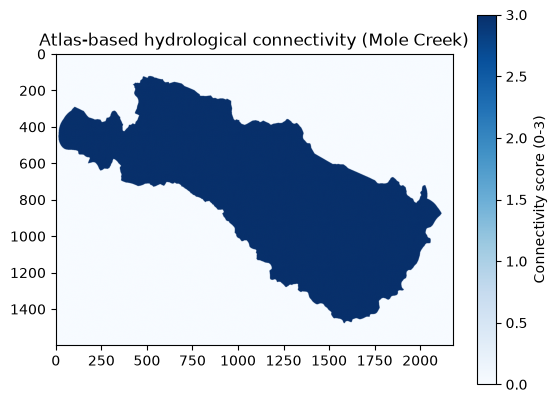

In [3]:
with rasterio.open(str(outpath / "dem_mc_EPSG7855.tif")) as dem_src:
    template_transform = dem_src.transform
    template_shape = (dem_src.height, dem_src.width)
    template_crs = dem_src.crs

connectivity_raster = rasterize(
    [(geom, val) for geom, val in zip(karst_mc.geometry, karst_mc["connectivity"])],
    out_shape=template_shape, transform=template_transform, fill=0, dtype="uint8",
)
profile = {
    "driver": "GTiff", "height": template_shape[0], "width": template_shape[1],
    "count": 1, "dtype": "uint8", "crs": template_crs, "transform": template_transform, "nodata": 255,
}
with rasterio.open(outpath / "connectivity_atlas_mc_EPSG7855.tif", "w", **profile) as dst:
    dst.write(connectivity_raster, 1)

plt.imshow(connectivity_raster, cmap="Blues")
plt.title("Atlas-based hydrological connectivity (Mole Creek)")
plt.colorbar(label="Connectivity score (0-3)")
plt.show()

## 3.3 DEM-derived flow accumulation 

Via WhiteboxTools: fill depressions, compute D8 flow
direction and accumulation. No PyQGIS involved.

In [4]:
wbt = whitebox.WhiteboxTools()
wbt.set_working_dir(str(outpath))
wbt.verbose = False

wbt.fill_depressions("dem_mc_EPSG7855.tif", "dem_mc_filled.tif")
wbt.d8_pointer("dem_mc_filled.tif", "dem_mc_pointer.tif")
wbt.d8_flow_accumulation("dem_mc_filled.tif", "flow_accum_mc_EPSG7855.tif", out_type="cells")

with rasterio.open(outpath / "flow_accum_mc_EPSG7855.tif") as src:
    flow_accum = src.read(1)
    flow_nodata = src.nodata

print("Flow accumulation computed:", flow_accum.shape)

Decompressing WhiteboxTools_darwin_m_series.zip ...
WhiteboxTools package directory: /opt/anaconda3/envs/KGG375_AT3/lib/python3.12/site-packages/whitebox
Flow accumulation computed: (1599, 2178)


## 3.4 Compare: do DEM-derived drainage channels coincide with Atlas connectivity?

A raw mean over broad zones washes out the signal (flow accumulation is
dominated by a handful of narrow channel cells; most of any zone is
hillslope with near-1 accumulation). Instead: threshold flow
accumulation into a channel network (top 5%), then check what fraction
of channel cells falls within Atlas-mapped connectivity zones vs.
background — plus a visual overlay, since the statistic alone doesn't
tell the whole story.

Channel network: top 5% by flow accumulation (threshold=166 cells)
Connectivity=0: 4.6% of cells are channel cells (n=652116)
Connectivity=3: 5.3% of cells are channel cells (n=1196294)


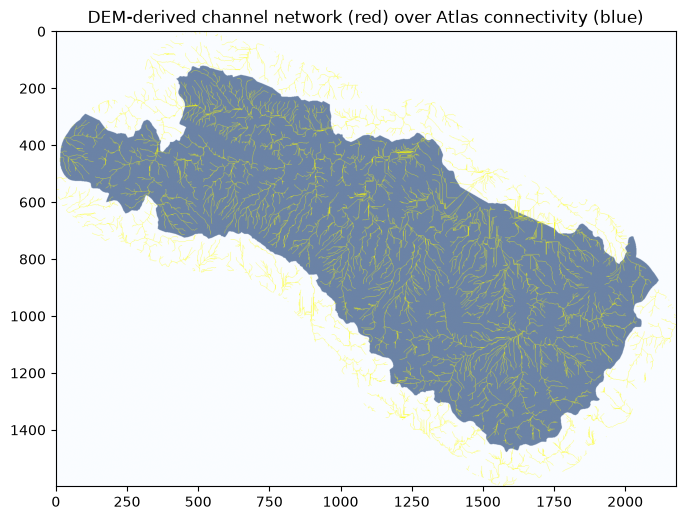

In [5]:
valid = flow_accum != flow_nodata
channel_threshold = np.percentile(flow_accum[valid], 95)
is_channel = valid & (flow_accum >= channel_threshold)
print(f"Channel network: top 5% by flow accumulation (threshold={channel_threshold:.0f} cells)")

for level in sorted(np.unique(connectivity_raster)):
    mask_level = (connectivity_raster == level) & valid
    if mask_level.sum() > 0:
        pct_channel = is_channel[mask_level].mean() * 100
        print(f"Connectivity={level}: {pct_channel:.1f}% of cells are channel cells (n={mask_level.sum()})")

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(connectivity_raster, cmap="Blues", alpha=0.6)
ax.imshow(np.where(is_channel, 1, np.nan), cmap="autumn_r")
plt.title("DEM-derived channel network (red) over Atlas connectivity (blue)")
plt.show()

## Result: a weak, non-contradictory signal

The channel-density check comes out close for both classes (roughly
4-5% either way) which is a weak signal. That's a
legitimate result to report as-is: the revised workflow plan explicitly
doesn't require sophisticated statistical validation here, just a
plausibility check. Worth stating as a limitation in `discussion.md`, the visual overlay is
more informative than the summary statistic for this particular check.

## Stage 3 outputs

- `connectivity_atlas_mc_EPSG7855.tif` — Atlas-based connectivity raster (0-3)
- `flow_accum_mc_EPSG7855.tif` — DEM-derived flow accumulation
- `karst_mc_EPSG7855.gpkg` — updated with connectivity columns

**Next (Stage 4):** combine Stage 2 (susceptibility) × Stage 3
(connectivity) into intrinsic karst vulnerability — still Mole Creek
prototype, before Stage 5 introduces land-use pressure.